In [1]:
# Automatic Google Colab setup: clones the repo to access the .py module
# and the dataset in this folder (no effect when run locally).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Base-Algorithms/03-MLP-Sklearn")
    get_ipython().system('pip install -q openpyxl')


# MLP with scikit-learn (equivalent to R's `neuralnet` package)

Translated from `Codigo01_Seno_MLP_neuralnet.R` and `Codigo01_FUNCAO_MLP_neuralnet.R`.

The previous notebook (`02-MLP-Manual-Backpropagation/`) implemented
backpropagation by hand. In practice, one uses a mature library to train
MLPs — in R, the `neuralnet` package; in Python,
`sklearn.neural_network.MLPRegressor` plays the same role: the same
architecture (one hidden layer, configurable activation, linear output),
but with robust numerical optimization (here, L-BFGS) and no need to derive
gradients by hand.

This notebook repeats the experiment on two datasets: the noisy sine
(`Seno.xlsx`, used before) and a more irregular function (`funcao.xlsx`,
which also provides `xgrd`/`ymean` — the true, noise-free target function,
for visual comparison).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mlp_sklearn import load_data, fit_mlp, predict

plt.rcParams["figure.figsize"] = (7, 4.5)


## Case 1: sine function

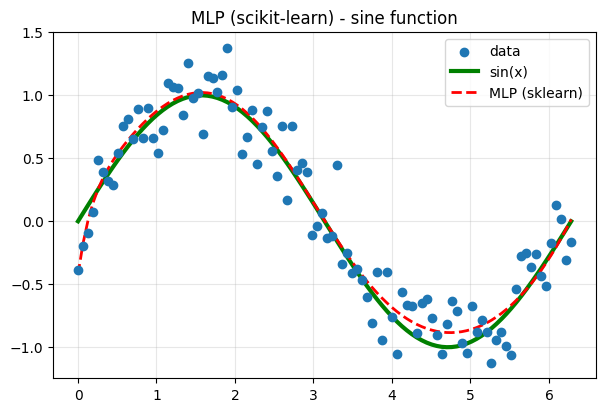

In [3]:
dt_sine = load_data("data/Seno.xlsx")
x_sine = dt_sine["x"].to_numpy(dtype=float)
y_sine = dt_sine["y"].to_numpy(dtype=float)

model_sine = fit_mlp(x_sine, y_sine, hidden_layer_sizes=(6,), activation="tanh")
y_hat_sine = predict(model_sine, x_sine)

order = np.argsort(x_sine)
plt.scatter(x_sine, y_sine, color="tab:blue", label="data", zorder=3)
plt.plot(x_sine[order], np.sin(x_sine[order]), color="green", lw=3, label="sin(x)")
plt.plot(x_sine[order], y_hat_sine[order], color="red", lw=2, ls="--", label="MLP (sklearn)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP (scikit-learn) - sine function")
plt.show()


## Case 2: generic function (`funcao.xlsx`)

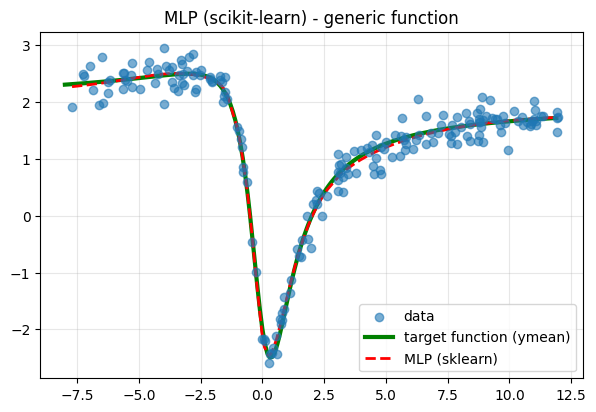

In [4]:
dt_fn = load_data("data/funcao.xlsx")
x_fn = dt_fn["x"].to_numpy(dtype=float)
y_fn = dt_fn["y"].to_numpy(dtype=float)

model_fn = fit_mlp(x_fn, y_fn, hidden_layer_sizes=(6,), activation="tanh")
y_hat_fn = predict(model_fn, x_fn)

order_fn = np.argsort(x_fn)
plt.scatter(x_fn, y_fn, color="tab:blue", label="data", zorder=3, alpha=0.6)
plt.plot(dt_fn["xgrd"], dt_fn["ymean"], color="green", lw=3, label="target function (ymean)")
plt.plot(x_fn[order_fn], y_hat_fn[order_fn], color="red", lw=2, ls="--", label="MLP (sklearn)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP (scikit-learn) - generic function")
plt.show()


### Choosing the hyperparameters

- **`hidden_layer_sizes=(6,)`**: same topology used in the original R
  script (`hidden = c(6)`), enough to capture the curvature of both
  functions without being so large it memorizes noise.
- **`activation="tanh"`**: mirrors the R script's `act.fct = 'tanh'`;
  smooth, symmetric saturation around zero, suited to oscillating
  functions like a sine.
- **`solver="lbfgs"` vs. the default `"adam"`**: these are two different
  strategies for finding the weights that minimize the cost function.

  - **`adam`** looks at only a small chunk of the data at a time
    (mini-batch), takes a step, looks at another chunk, takes another step —
    it's *stochastic* (has randomness), designed for large datasets where
    processing everything at once would be expensive.
  - **`lbfgs`** looks at the **entire** dataset at every step and uses an
    approximation of the cost function's curvature (not just the
    gradient/slope, but how the gradient itself is changing) to take
    smarter steps — it's deterministic, no randomness involved.

  With 100-200 points, looking at the whole dataset each step is cheap, so
  `lbfgs` converges faster and more stably, without needing the randomness
  `adam` relies on to handle large datasets. If this dataset had millions of
  rows, `lbfgs` would become too expensive (recomputing everything every
  step) and `adam` would be the better trade-off — which is exactly why
  algorithm 5, with many more training runs, switches to `adam`.


## Interpreting the metrics

`model.score()` in scikit-learn returns R² directly. As formally defined in
Prof. Costa's textbook (Ch. 2.7, p. 41):

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

where $SS_{tot}$ is how much $y$ varies around its own mean (the simplest
possible baseline — always predicting the mean), and $SS_{res}$ is the
error left over after the model. $R^2=1$ means zero error (perfect fit);
$R^2=0$ means the model is no better than guessing the mean; $R^2$ can even
be **negative** if the model does worse than that baseline. Combined with
RMSE, this summarizes how well the MLP recovers the target function's shape
from noisy data.


In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


print("Sine     -> R2:", round(model_sine.score(x_sine.reshape(-1, 1), y_sine), 4),
      "| RMSE:", round(rmse(y_sine, y_hat_sine), 4))
print("Function -> R2:", round(model_fn.score(x_fn.reshape(-1, 1), y_fn), 4),
      "| RMSE:", round(rmse(y_fn, y_hat_fn), 4))


Sine     -> R2: 0.9258 | RMSE: 0.1941
Function -> R2: 0.9756 | RMSE: 0.1968


## Conclusion

`MLPRegressor` reproduces R's `neuralnet` behavior with far less code than
the manual implementation, at the cost of less control over the
optimization process. The next notebooks explore, respectively,
regularization (`04-Polynomial-Regression-Ridge/`) and a systematic
hyperparameter search (`05-MLP-Hyperparameter-Search/`).
